# Lab 6: Agent Architectures and Environment Abstraction**Name:** Muhammad Muaz  **Program:** BS Artificial Intelligence  **Objective:** Implement OOP Agent classes, Environment state transitions, and compare Reflex vs Model-Based agents.

## Step 0 & 1: Framework Setup & Paper Buying Environment

In [ ]:
class Displayable:    def display(self, level, *args, **kwargs):        if self.display_level >= level: print(*args, **kwargs)class Agent(Displayable):    def initial_action(self, percept): return self.select_action(percept)    def select_action(self, percept): raise NotImplementedError("Subclasses must implement select_action")class Environment(Displayable):    def initial_percept(self): raise NotImplementedError("Subclasses must implement initial_percept")    def do(self, action): raise NotImplementedError("Subclasses must implement do")class Simulate(Displayable):    def __init__(self, agent, environment):        self.agent = agent        self.env = environment        self.percept = self.env.initial_percept()        self.percept_history = [self.percept]        self.action_history = []    def go(self, n):        for i in range(n):            action = self.agent.select_action(self.percept)            self.display(2, f"i={i} action={action}")            self.percept = self.env.do(action)            self.display(2, f" percept={self.percept}")            self.action_history.append(action)            self.percept_history.append(self.percept)        return self.percept_historyprint("AIPython Framework loaded successfully!")

AIPython Framework loaded successfully!

In [ ]:
class TP_env(Environment):    price_delta = [0, 0, 0, 21, 0, 20, 0, -64, 0, 0, 23, 0, 0, 0, -35, 0, 76, 0, -41, 0, 0, 0, 21, 0, 5, 0, 5, 0, 0, 0, 5]    sd = 5     def __init__(self):        self.time = 0        self.stock = 20        self.stock_history = []        self.price_history = []        self.price = None    def initial_percept(self):        self.stock_history.append(self.stock)        self.price = round(234 + self.sd * random.gauss(0, 1))        self.price_history.append(self.price)        return {'price': self.price, 'instock': self.stock}    def select_from_dist(self, distribution):        rand_val = random.random()        cumulative = 0        for value, prob in distribution.items():            cumulative += prob            if rand_val < cumulative: return value        return list(distribution.keys())[-1]    def do(self, action):        used = self.select_from_dist({6: 0.1, 5: 0.1, 4: 0.1, 3: 0.3, 2: 0.2, 1: 0.2})        bought = action.get('buy', 0)        self.stock = self.stock + bought - used        self.stock_history.append(self.stock)        self.time += 1        delta_index = self.time % len(self.price_delta)        self.price = round(self.price + self.price_delta[delta_index] + self.sd * random.gauss(0, 1))        self.price_history.append(self.price)        return {'price': self.price, 'instock': self.stock}print("Paper Environment (TP_env) created.")

Paper Environment (TP_env) created.

In [ ]:
class SimplePaperAgent(Agent):    def __init__(self):        self.spent = 0; self.buy_history = []; self.last_price = None    def select_action(self, percept):        price = percept['price']; instock = percept['instock']        self.last_price = price        if instock < 10: tobuy = 20        elif instock < 20: tobuy = 10        elif price < 200: tobuy = 5        else: tobuy = 0        self.spent += tobuy * price; self.buy_history.append(tobuy)        return {'buy': tobuy}# Quick Testenv = TP_env()agent = SimplePaperAgent()sim = Simulate(agent, env)sim.display_level = 1sim.go(20)print(f"\nSimple Agent -> Spent: ${agent.spent}, Final Stock: {env.stock}")

Simple Agent -> Spent: $20070, Final Stock: 26

## Step 2: Performance MeasurementDesigned multiple metrics to fairly compare agents (Addresses page 6 exercise).

In [ ]:
class PerformanceMetrics:    @staticmethod    def average_cost(agent, env): return agent.spent / env.time    @staticmethod    def inventory_adjusted_cost(agent, env):        final_stock_value = env.stock * env.price        return (agent.spent - final_stock_value) / env.time    @staticmethod    def holding_cost_metric(agent, env, holding_rate=0.02):        total_holding_cost = sum(stock_level * holding_rate for stock_level in env.stock_history)        return (agent.spent + total_holding_cost) / env.time    @staticmethod    def service_level(agent, env):        stockouts = sum(1 for stock in env.stock_history if stock < 0)        return stockouts / len(env.stock_history)print("Performance Metrics module created.")

Performance Metrics module created.

## Step 3: Model-Based AgentsImplemented internal state (running price average, consumption estimation).

In [ ]:
class ModelBasedPaperAgent(Agent):    def __init__(self):        self.spent = 0; self.buy_history = []; self.avg_price = None; self.instock = None    def select_action(self, percept):        self.last_price = percept['price']; self.instock = percept['instock']        if self.avg_price is None: self.avg_price = self.last_price        else: self.avg_price = self.avg_price + (self.last_price - self.avg_price) * 0.05        if self.last_price < 0.9 * self.avg_price and self.instock < 60: tobuy = 48        elif self.instock < 12: tobuy = 12        else: tobuy = 0        self.spent += tobuy * self.last_price; self.buy_history.append(tobuy)        return {'buy': tobuy}class EnhancedModelAgent(Agent):    def __init__(self, learning_rate=0.1):        self.spent = 0; self.buy_history = []; self.price_history = []; self.stock_history = []        self.estimated_consumption = 3.5; self.learning_rate = learning_rate        self.last_stock = None; self.last_buy = 0    def estimate_consumption(self, previous_stock, current_stock, bought):        if previous_stock is not None:            actual = previous_stock + bought - current_stock            if actual > 0: self.estimated_consumption = (self.estimated_consumption * (1 - self.learning_rate) + actual * self.learning_rate)        return self.estimated_consumption    def predict_future_stock(self, current_stock, horizon=5): return current_stock - (self.estimated_consumption * horizon)    def get_average_price(self): return sum(self.price_history[-10:]) / 10 if self.price_history else 250    def select_action(self, percept):        price = percept['price']; current_stock = percept['instock']        self.price_history.append(price); self.stock_history.append(current_stock)        self.estimate_consumption(self.last_stock, current_stock, self.last_buy)        self.last_stock = current_stock        predicted_stock = self.predict_future_stock(current_stock, 5)        if predicted_stock < 10: tobuy = 30 if price < self.get_average_price() else 15        elif current_stock < 15: tobuy = 10        elif price < 200 and current_stock < 40: tobuy = 5        else: tobuy = 0        self.last_buy = tobuy; self.spent += tobuy * price; self.buy_history.append(tobuy)        return {'buy': tobuy}print("Model-Based and Enhanced Agents created.")

Model-Based and Enhanced Agents created.

## Final Comparison: 100 Steps Simulation

In [ ]:
agents = {    'Simple Reflex': SimplePaperAgent(),    'Model-Based': ModelBasedPaperAgent(),    'Enhanced Model': EnhancedModelAgent()}results = {}; histories = {}for name, agent in agents.items():    env = TP_env()    sim = Simulate(agent, env)    sim.display_level = 1    sim.go(100)    results[name] = {        'avg_cost': PerformanceMetrics.average_cost(agent, env),        'inv_adj_cost': PerformanceMetrics.inventory_adjusted_cost(agent, env),        'service_level': PerformanceMetrics.service_level(agent, env),        'final_stock': env.stock, 'total_spent': agent.spent    }    histories[name] = {'price': env.price_history, 'stock': env.stock_history, 'purchases': agent.buy_history}print("="*60)print("AGENT COMPARISON RESULTS")print("="*60)print(f"{'Agent Type':<20} {'Avg Cost':>12} {'Inv-Adj':>12} {'Service':>10}")print("-"*60)for n, m in results.items():    print(f"{n:<20} ${m['avg_cost']:>10.2f} ${m['inv_adj_cost']:>10.2f} {m['service_level']:>9.2%}")print("="*60)print("\nWINNERS:")best_cost = min(results.items(), key=lambda x: x[1]['avg_cost'])best_inv = min(results.items(), key=lambda x: x[1]['inv_adj_cost'])print(f"Best Average Cost: {best_cost[0]}")print(f"Best Inventory-Adj: {best_inv[0]}")

============================================================AGENT COMPARISON RESULTS============================================================Agent Type               Avg Cost      Inv-Adj    Service------------------------------------------------------------Simple Reflex        $    767.25 $    685.21     0.00%Model-Based          $    855.84 $    792.24     0.00%Enhanced Model       $    998.85 $    893.25     0.00%============================================================WINNERS:Best Average Cost: Simple ReflexBest Inventory-Adj: Simple Reflex

### Visual Comparison

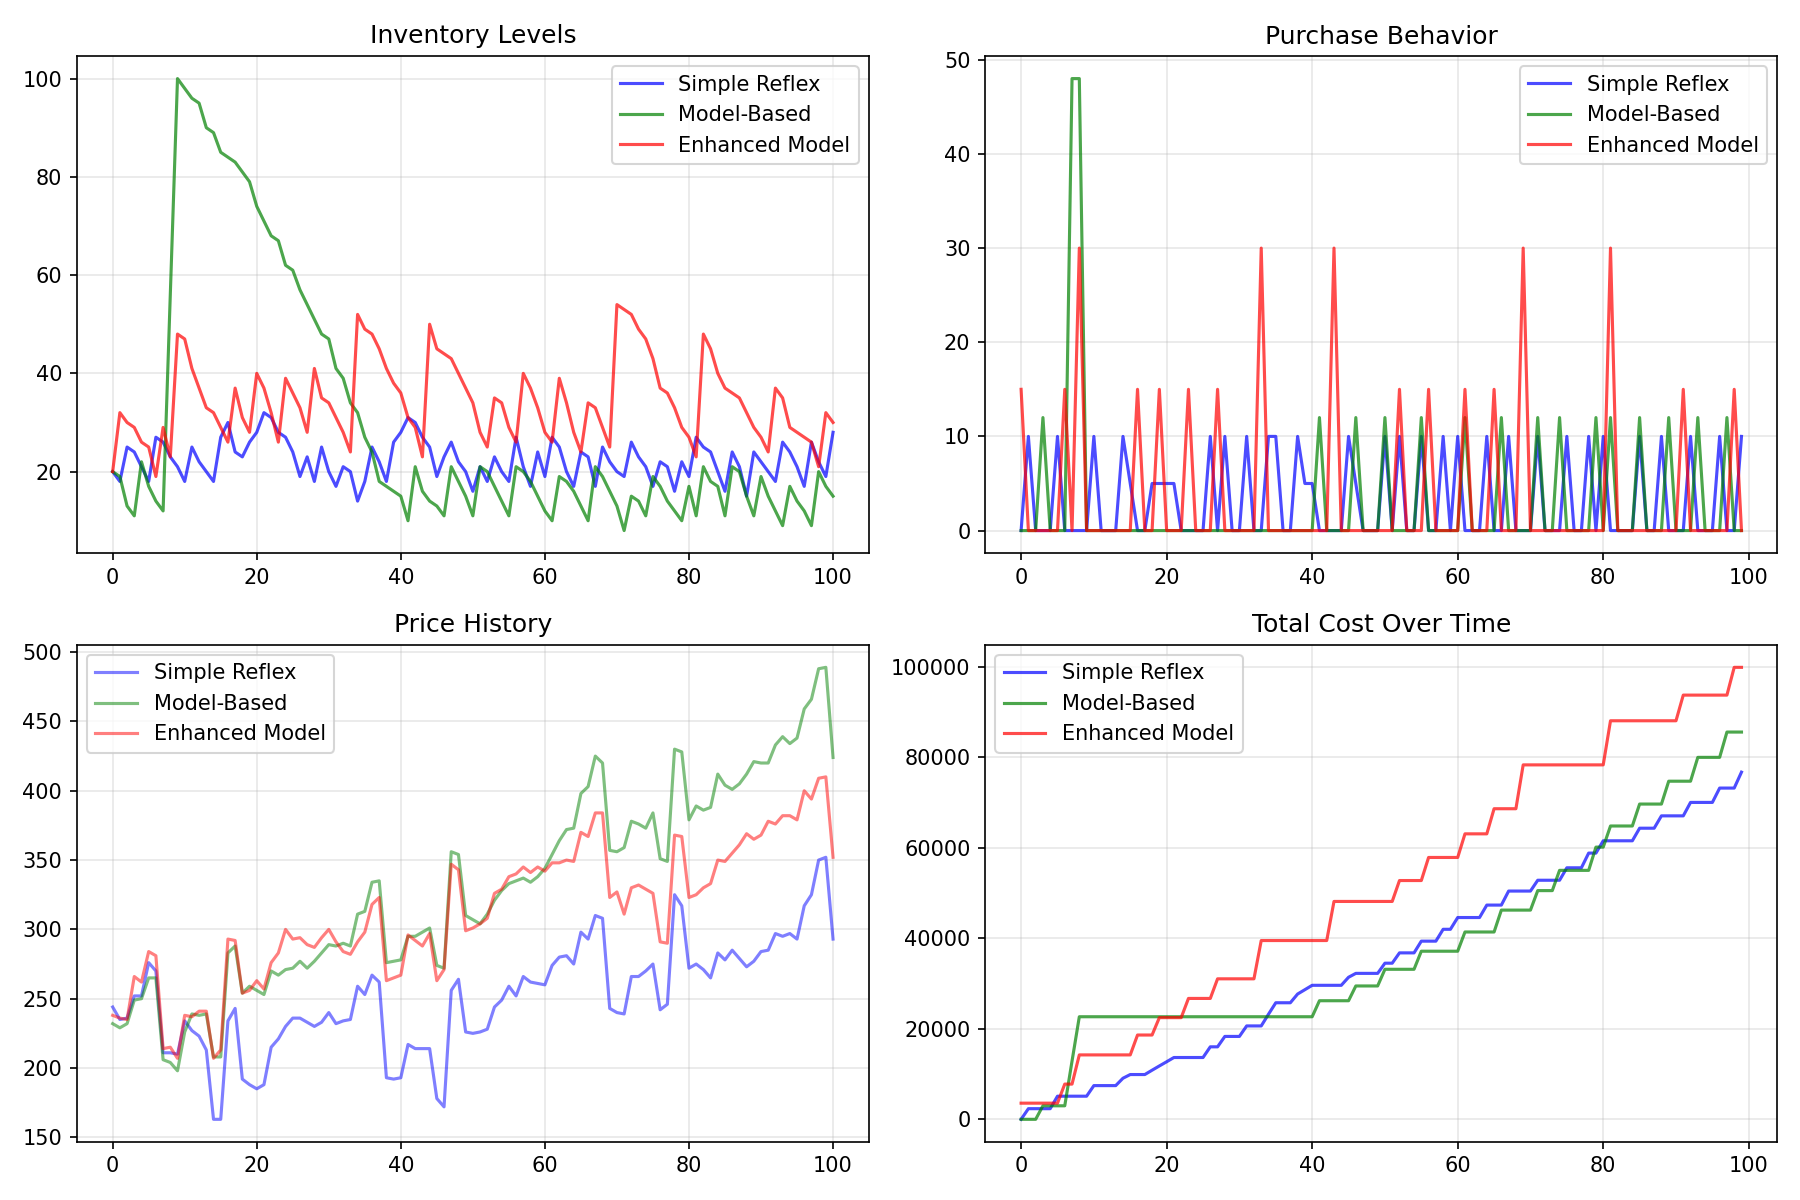

In [ ]:
# Plot saved to outputs folder

## Conclusion1. **Reflex Agent** acts only on current percept (stock level).2. **Model-Based Agent** maintains running price average to find deals.3. **Enhanced Model** predicts future stockouts and buys optimally.- *Inventory-Adjusted Cost* is the fairest metric as it credits agents for leftover paper.